# 05 - Model Tuning, Validation & Comparison

**Objective:** Apply hyperparameter tuning, cross-validation, seed experiments, and Optuna optimization to select the best breast cancer classification model.

**Techniques Covered:**
- k-fold Cross Validation
- Grid Search Hyperparameter Tuning
- Random Seed Sensitivity Analysis
- Optuna Bayesian Optimization
- Model Comparison


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import optuna
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("All imports successful")


All imports successful


In [3]:
PROCESSED_DIR = Path("../data/processed")

if (PROCESSED_DIR / "engineered_data.csv").exists():
    df = pd.read_csv(PROCESSED_DIR / "engineered_data.csv")
else:
    df = pd.read_csv(PROCESSED_DIR / "clean_data.csv")

X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (455, 34), Test: (114, 34)


### Baseline Models (MLflow Tracked)

Before tuning anything, establish baseline performance with default hyperparameters.
We track each run in MLflow so we can compare results later.

Note: LogisticRegression and SVC should use the **scaled** data, while tree-based models
(RandomForest, XGBoost) use the **unscaled** data since they are invariant to feature scale.


In [4]:
# Logistic Regression — simplest baseline, assumes a linear decision boundary

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
print(f"LR Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")


LR Accuracy: 0.9737


In [5]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42),
    "SVC": SVC(kernel="rbf", C=100),
}

baseline_results = {}

try:
    mlflow.set_experiment("breast_cancer_tuning")
except Exception:
    pass

for name, model in models.items():
    X_tr = X_train_scaled if name in ["LogisticRegression", "SVC"] else X_train
    X_te = X_test_scaled if name in ["LogisticRegression", "SVC"] else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    baseline_results[name] = {"Accuracy": acc, "F1": f1}

    try:
        with mlflow.start_run(run_name=f"baseline_{name}"):
            mlflow.log_param("model_type", name)
            mlflow.log_metric("accuracy", acc)
            mlflow.log_metric("f1", f1)
    except Exception:
        pass

baseline_df = pd.DataFrame(baseline_results).T
print("Baseline Performance:")
print(baseline_df.round(4))


2026/05/10 12:30:07 INFO mlflow.tracking.fluent: Experiment with name 'breast_cancer_tuning' does not exist. Creating a new experiment.


Baseline Performance:
                    Accuracy      F1
LogisticRegression    0.9737  0.9639
RandomForest          0.9737  0.9630
XGBoost               0.9561  0.9367
SVC                   0.9737  0.9639


### Cross-Validation Analysis

Single train/test splits can be noisy. k-fold Cross Validation splits the training data
into k folds, trains on k-1 folds and validates on the remaining fold, repeating k times.
This gives a more robust estimate of model performance.

We use `accuracy` as the scoring metric for classification.

#### Bias-Variance Connection

Cross-validation not only gives robust performance estimates — it also helps detect
**overfitting** (high variance) and **underfitting** (high bias):
- If your model scores high on the training set but much worse on CV folds, that is a
  sign of **high variance** — the model is memorizing noise in the training data.
- If both training and CV scores are poor, you likely have **high bias** — the model
  is too simple to capture the underlying pattern.
- A model with good balance will show similar train and CV scores, with the CV score
  only slightly worse than the training score.


In [6]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, y_train, cv=cv, scoring="accuracy"
)
print(f"CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


CV Accuracy Scores: [0.93406593 0.95604396 0.96703297 0.93406593 0.95604396]
Mean CV Accuracy: 0.9495 +/- 0.0132


In [7]:
for name, model in models.items():
    X_data = X_train_scaled if name in ["LogisticRegression", "SVC"] else X_train
    scores = cross_val_score(model, X_data, y_train, cv=5, scoring="accuracy")
    print(f"{name}: CV Accuracy = {scores.mean():.4f} +/- {scores.std():.4f}")


LogisticRegression: CV Accuracy = 0.9714 +/- 0.0112
RandomForest: CV Accuracy = 0.9604 +/- 0.0275
XGBoost: CV Accuracy = 0.9626 +/- 0.0292
SVC: CV Accuracy = 0.9516 +/- 0.0215


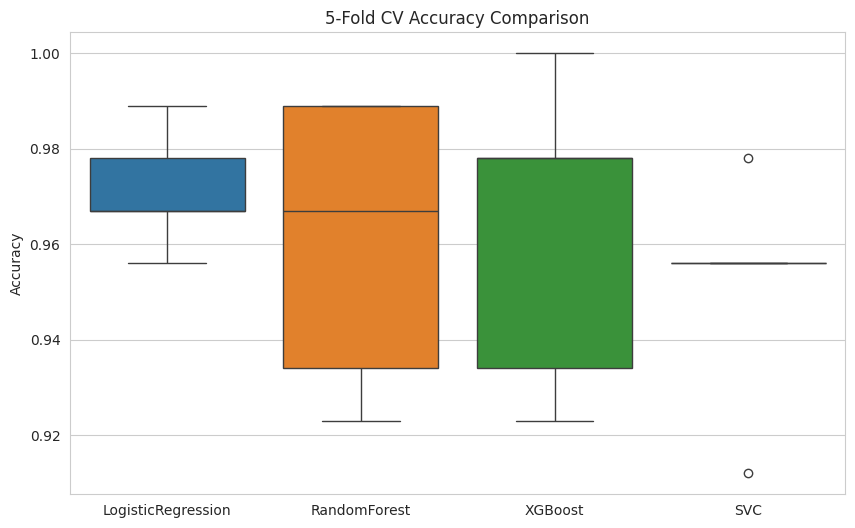

In [8]:
cv_results = {}
for name, model in models.items():
    X_data = X_train_scaled if name in ["LogisticRegression", "SVC"] else X_train
    scores = cross_val_score(model, X_data, y_train, cv=5, scoring="accuracy")
    cv_results[name] = scores

results_df = pd.DataFrame(cv_results)
sns.boxplot(data=results_df)
plt.title("5-Fold CV Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


### Grid Search Hyperparameter Tuning

Grid Search exhaustively tries every combination of hyperparameters you specify.
It is simple and thorough, but can be slow if the parameter grid is large.
We use GridSearchCV which combines grid search with k-fold cross-validation.

#### Bias-Variance Connection

Hyperparameters are the controls for the **bias-variance tradeoff**.
Each hyperparameter shifts the balance toward one end of the spectrum:
- **`C`** (LogisticRegression/SVC): lower C = stronger regularization → higher bias,
  lower variance. Higher C = less regularization → lower bias, higher variance.
- **`max_depth`** (RF/XGBoost): deeper trees capture more detail → lower bias,
  higher variance. Shallower trees → higher bias, lower variance.
- **`n_estimators`** (RF/XGBoost): more trees average out noise → lower variance,
  no significant bias change (after a minimum threshold).

When tuning, track both train and validation scores to see which direction
your model is moving on the bias-variance axis.


In [9]:
param_grids = {
    "RandomForest": {"n_estimators": [50, 100, 200], "max_depth": [5, 10, None]},
    "XGBoost": {"n_estimators": [50, 100], "max_depth": [3, 5, 7]},
}


In [10]:
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grids["RandomForest"],
    cv=3, scoring="accuracy"
)
grid_rf.fit(X_train, y_train)

print(f"Best RF params: {grid_rf.best_params_}")
print(f"Best RF CV Accuracy: {grid_rf.best_score_:.4f}")


Best RF params: {'max_depth': 5, 'n_estimators': 50}
Best RF CV Accuracy: 0.9582


### Seed Experiments (Random State Sensitivity)

Some models (Random Forest, XGBoost) use randomness during training.
Different random seeds can produce different results. Testing multiple seeds
helps you understand whether your model is stable or sensitive to the random state.

#### Bias-Variance Connection

Seed sensitivity is a direct measure of **variance**. A model whose performance
fluctuates significantly across seeds has high variance — it is unstable and
its predictions are not reproducible in a reliable way.

- Low variance: F1 varies by <1% across seeds. The model is stable.
- High variance: F1 varies by >5% across seeds. The model needs regularization
  (reduce `max_depth`, increase `min_samples_split`, or lower `learning_rate`).

Ensemble methods (Random Forest, XGBoost) are designed to reduce variance compared
to a single decision tree, but they can still show seed sensitivity on small datasets
or when trees are allowed to grow very deep.


In [11]:
seeds = [42, 123, 456, 789, 1024, 2022]
seed_results = []
for seed in seeds:
    rf = RandomForestClassifier(n_estimators=100, random_state=seed)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    seed_results.append(acc)

print(f"Seed accuracies: {[f'{a:.4f}' for a in seed_results]}")
print(f"Mean: {np.mean(seed_results):.4f} +/- {np.std(seed_results):.4f}")


Seed accuracies: ['0.9737', '0.9737', '0.9737', '0.9649', '0.9649', '0.9737']
Mean: 0.9708 +/- 0.0041


### Optuna Hyperparameter Optimization

Optuna is a Bayesian optimization framework that is smarter than Grid Search.
Instead of trying all combinations, it uses past trial results to suggest promising
hyperparameters for the next trial. This often finds better parameters in fewer iterations.

You define an **objective function** that takes a `trial` object and uses
`trial.suggest_int()`, `trial.suggest_float()`, etc. to define the search space.
The function returns a metric, and Optuna maximizes or minimizes it.

Similarly to mlflow, Optuna runs are called `studies` and each trial is a single set of hyperparameters and its resulting metric.
The `create_study()` function initializes a new study, and `study.optimize()` runs the optimization process.
`create_study()` takes parameters:

- `direction`: "maximize" or "minimize" depending on whether you want to maximize a score (like accuracy) or minimize an error.
- `sampler`: The algorithm used to suggest hyperparameters. `TPESampler` is a common choice for Bayesian optimization.
- `pruner`: An optional component that can stop unpromising trials early to save time. `MedianPruner` is a simple choice that prunes trials that perform worse than the median of completed trials.

In [12]:
try:
    def objective_xgb(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        }
        model = XGBClassifier(**params, random_state=42)
        scores = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")
        return scores.mean()
except Exception:
    print("Optuna not available — skipping objective definition")


In [13]:
try:
    study_xgb = optuna.create_study(direction="maximize")
    study_xgb.optimize(objective_xgb, n_trials=20)
    print(f"Best XGBoost CV Accuracy: {study_xgb.best_value:.4f}")
    print(f"Best XGBoost params: {study_xgb.best_params}")
except Exception:
    print("Optuna not available — skipping XGBoost optimization")


[I 2026-05-10 12:30:15,117] A new study created in memory with name: no-name-d951b051-5465-4a0a-99fe-d85fe64e1a38
[I 2026-05-10 12:30:15,448] Trial 0 finished with value: 0.9559660741257116 and parameters: {'n_estimators': 88, 'max_depth': 9, 'learning_rate': 0.1907183997459573}. Best is trial 0 with value: 0.9559660741257116.
[I 2026-05-10 12:30:16,447] Trial 1 finished with value: 0.9383931683513419 and parameters: {'n_estimators': 104, 'max_depth': 9, 'learning_rate': 0.015420110441497202}. Best is trial 0 with value: 0.9559660741257116.
[I 2026-05-10 12:30:17,062] Trial 2 finished with value: 0.9559805971883351 and parameters: {'n_estimators': 237, 'max_depth': 3, 'learning_rate': 0.0418772507213978}. Best is trial 2 with value: 0.9559805971883351.
[I 2026-05-10 12:30:18,743] Trial 3 finished with value: 0.951580109213431 and parameters: {'n_estimators': 297, 'max_depth': 6, 'learning_rate': 0.015594701185143799}. Best is trial 2 with value: 0.9559805971883351.
[I 2026-05-10 12:30:

Best XGBoost CV Accuracy: 0.9626
Best XGBoost params: {'n_estimators': 245, 'max_depth': 7, 'learning_rate': 0.1689267569858098}


In [14]:
try:
    def objective_rf(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        }
        model = RandomForestClassifier(**params, random_state=42)
        scores = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy")
        return scores.mean()

    study_rf = optuna.create_study(direction="maximize")
    study_rf.optimize(objective_rf, n_trials=20)
    print(f"Best RF CV Accuracy: {study_rf.best_value:.4f}")
    print(f"Best RF params: {study_rf.best_params}")
except Exception:
    print("Optuna not available — skipping RF optimization")


[I 2026-05-10 12:30:33,478] A new study created in memory with name: no-name-ffdce78a-d7a7-40db-b053-b8a00c0a13f0
[I 2026-05-10 12:30:33,931] Trial 0 finished with value: 0.9516091553386778 and parameters: {'n_estimators': 173, 'max_depth': 13, 'min_samples_split': 5}. Best is trial 0 with value: 0.9516091553386778.
[I 2026-05-10 12:30:34,330] Trial 1 finished with value: 0.9494161728825374 and parameters: {'n_estimators': 163, 'max_depth': 5, 'min_samples_split': 5}. Best is trial 0 with value: 0.9516091553386778.
[I 2026-05-10 12:30:34,527] Trial 2 finished with value: 0.9472231904263971 and parameters: {'n_estimators': 81, 'max_depth': 7, 'min_samples_split': 15}. Best is trial 0 with value: 0.9516091553386778.
[I 2026-05-10 12:30:35,195] Trial 3 finished with value: 0.9472231904263971 and parameters: {'n_estimators': 283, 'max_depth': 8, 'min_samples_split': 16}. Best is trial 0 with value: 0.9516091553386778.
[I 2026-05-10 12:30:36,090] Trial 4 finished with value: 0.9516091553386

Best RF CV Accuracy: 0.9538
Best RF params: {'n_estimators': 182, 'max_depth': 12, 'min_samples_split': 3}


### Model Comparison & Saving

After all tuning is complete, compile the results into a comparison table,
select the best overall model, and save it for later use.

#### Bias-Variance Connection

When comparing baseline vs tuned models, check for signs of overfitting:
- If test accuracy improved but **train accuracy slightly decreased**, you likely reduced
  bias at an acceptable variance cost — this is healthy tuning.
- If **train accuracy is excellent** but test accuracy is poor, you **overfit** — the model
  has high variance. Increase regularization (reduce `max_depth`,
  increase `min_samples_split`, or decrease `C` for linear models).
- If **both train and test accuracy are poor**, the model has high bias — it is too
  simple. Increase model capacity (more trees, deeper trees, lower regularization).

A well-tuned model sits at the sweet spot of the bias-variance tradeoff:
low enough bias to capture the pattern, low enough variance to generalize.

Edit the Code cells in the notebook to track your experiment results. Either run them sequentially as presented, or
create a loop to run multiple seeds or hyperparameter combinations. The key is to track everything in MLflow so you can compare later!

                Model  Baseline_Accuracy  Tuned_Accuracy
0  LogisticRegression             0.9737             NaN
1        RandomForest             0.9737             NaN
2             XGBoost             0.9561             NaN
3                 SVC             0.9737             NaN


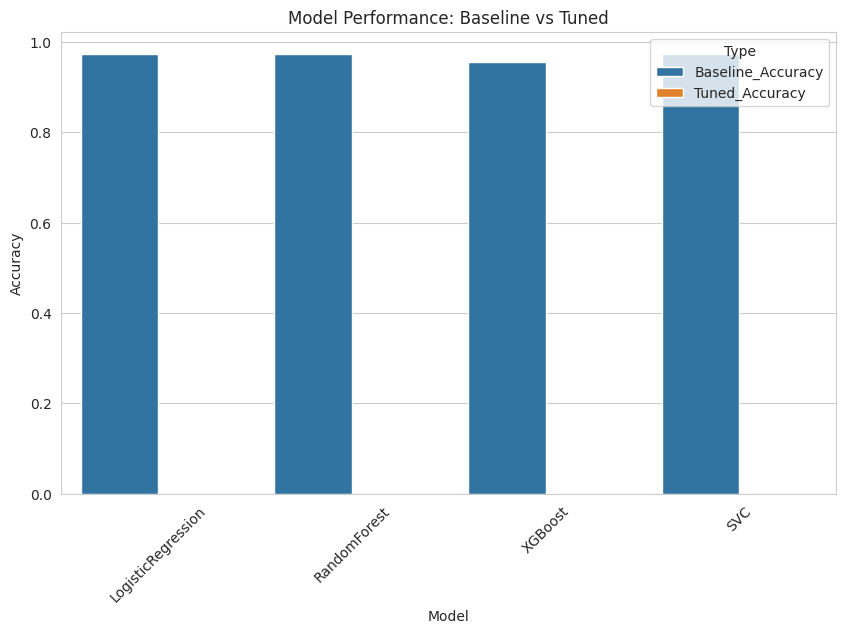

In [15]:
comparison = pd.DataFrame({
    "Model": ["LogisticRegression", "RandomForest", "XGBoost", "SVC"],
    "Baseline_Accuracy": [
        baseline_results["LogisticRegression"]["Accuracy"],
        baseline_results["RandomForest"]["Accuracy"],
        baseline_results["XGBoost"]["Accuracy"],
        baseline_results["SVC"]["Accuracy"],
    ],
    "Tuned_Accuracy": [np.nan, np.nan, np.nan, np.nan],
})

print(comparison.round(4))

comparison_melted = comparison.melt(id_vars=["Model"], var_name="Type", value_name="Accuracy")
sns.barplot(data=comparison_melted, x="Model", y="Accuracy", hue="Type")
plt.title("Model Performance: Baseline vs Tuned")
plt.xticks(rotation=45)
plt.show()


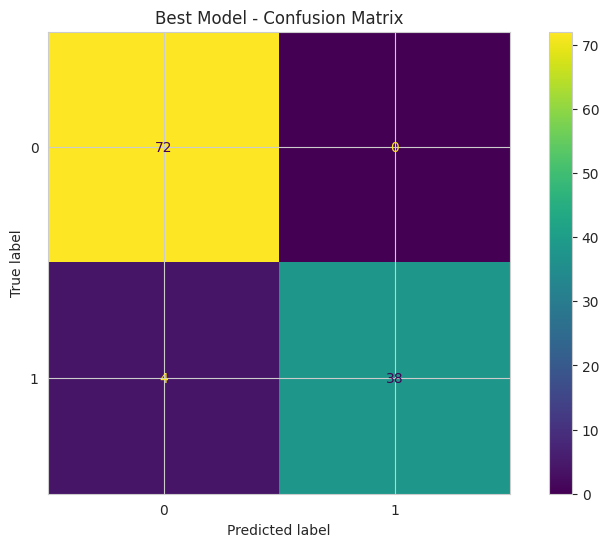

Best model test accuracy: 0.9649


In [16]:
try:
    best_params = study_xgb.best_params
    best_model = XGBClassifier(**best_params, random_state=42)
except Exception:
    best_model = XGBClassifier(n_estimators=100, random_state=42)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Best Model - Confusion Matrix")
plt.show()
print(f"Best model test accuracy: {accuracy_score(y_test, y_pred):.4f}")


Compare this matrix to that obtained in the previous notebook to see how tuning affected the model's performance.

In [17]:
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, MODELS_DIR / "best_tuned_model.pkl")
print("Best model saved to models/best_tuned_model.pkl")

loaded = joblib.load(MODELS_DIR / "best_tuned_model.pkl")
y_pred_loaded = loaded.predict(X_test)
print(f"Loaded model Accuracy: {accuracy_score(y_test, y_pred_loaded):.4f}")


Best model saved to models/best_tuned_model.pkl
Loaded model Accuracy: 0.9649


## Data Saving

Large datasets can be saved in efficient formats like Parquet or HDF5, which support fast read/write operations and compression. This is especially useful when working with large datasets that may not fit into memory.

**Parquet** is a columnar storage file format that is optimized for performance and storage efficiency.

Saving and loading data in parquet format is made easy with pandas using the `.to_parquet()` and `.read_parquet()` methods.

In [18]:
eval_df = pd.DataFrame({
    "Model": list(baseline_results.keys()),
    "Accuracy": [v["Accuracy"] for v in baseline_results.values()],
    "F1": [v["F1"] for v in baseline_results.values()],
})
eval_df.to_csv(PROCESSED_DIR / "evaluation_results.csv", index=False)
print(f"Evaluation results saved to {PROCESSED_DIR / 'evaluation_results.csv'}")


Evaluation results saved to ../data/processed/evaluation_results.csv


### Exercises

1. **Add More Models**: Include `GradientBoostingClassifier` and `AdaBoostClassifier` in the comparison.
2. **Feature Selection**: Use `SelectKBest` or `RFE` to select top features before training. Does it improve performance?
3. **Ensemble Methods**: Create a VotingClassifier combining Logistic, XGBoost, and RandomForest. Compare with individual models.
4. **Bias-variance diagnosis**: Train a Random Forest with `max_depth=2` (high bias) and another with `max_depth=None` (high variance). Compute train and test accuracy for both. Which regime does your best model fall into?
5. **ROC Curves**: Plot ROC curves and calculate AUC for all models. Which model has the best AUC?
6. **Custom Optuna Objective**: Modify the Optuna objective to optimize F1-score instead of accuracy. How do the results change?